In [111]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [112]:
df = pd.read_csv('../Dataset/synthetic_dna_dataset.csv')

In [113]:
df.head()

,Sample_ID,Sequence,GC_Content,AT_Content,Sequence_Length,Num_A,Num_T,Num_C,Num_G,kmer_3_freq,Mutation_Flag,Class_Label,Disease_Risk
0,SAMPLE_1,CTTTCGGGATACTTTTGGGATGGTCTTGGTCAAGGGTTTTAGCCCG...,50.0,50.0,100,22,28,19,31,0.986,0,Bacteria,High
1,SAMPLE_2,TTGACCAAATTTGATTGGAAGTGGTAAGCGCGTATTCCTAGCATCA...,45.0,55.0,100,27,28,22,23,0.486,1,Virus,Medium
2,SAMPLE_3,GCGTGAGTTCTAATTTAAAAAGTCGTAACACGTACCCCGGCGTGTA...,51.0,49.0,100,26,23,30,21,0.367,1,Bacteria,Low
3,SAMPLE_4,ACTACGCGGACAAGAACCAACAGAACCTGGTTTTCGCAAGGGAGTG...,55.0,45.0,100,28,17,23,32,0.404,0,Human,Medium
4,SAMPLE_5,TTCAATGCAGATTGAAAGTTACTTTCATCTGCCCTATGGGTCCCTT...,46.0,54.0,100,24,30,25,21,0.818,0,Human,High


In [114]:
df.shape

(3000, 13)

In [115]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Sample_ID        3000 non-null   str    
 1   Sequence         3000 non-null   str    
 2   GC_Content       3000 non-null   float64
 3   AT_Content       3000 non-null   float64
 4   Sequence_Length  3000 non-null   int64  
 5   Num_A            3000 non-null   int64  
 6   Num_T            3000 non-null   int64  
 7   Num_C            3000 non-null   int64  
 8   Num_G            3000 non-null   int64  
 9   kmer_3_freq      3000 non-null   float64
 10  Mutation_Flag    3000 non-null   int64  
 11  Class_Label      3000 non-null   str    
 12  Disease_Risk     3000 non-null   str    
dtypes: float64(3), int64(6), str(4)
memory usage: 304.8 KB


In [116]:
df.columns

Index(['Sample_ID', 'Sequence', 'GC_Content', 'AT_Content', 'Sequence_Length',
       'Num_A', 'Num_T', 'Num_C', 'Num_G', 'kmer_3_freq', 'Mutation_Flag',
       'Class_Label', 'Disease_Risk'],
      dtype='str')

In [117]:
df.describe(include='all')

,Sample_ID,Sequence,GC_Content,AT_Content,Sequence_Length,Num_A,Num_T,Num_C,Num_G,kmer_3_freq,Mutation_Flag,Class_Label,Disease_Risk
count,3000,3000,3000.000000,3000.000000,3000.0,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000,3000
unique,3000,3000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,3
top,SAMPLE_1,CTTTCGGGATACTTTTGGGATGGTCTTGGTCAAGGGTTTTAGCCCG...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Bacteria,High
freq,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,761,1046
mean,NaN,NaN,50.120000,49.880000,100.0,24.950667,24.929333,25.004000,25.116000,0.547738,0.496667,NaN,NaN
std,NaN,NaN,5.062688,5.062688,0.0,4.317458,4.317702,4.349056,4.329603,0.258521,0.500072,NaN,NaN
min,NaN,NaN,34.000000,34.000000,100.0,11.000000,9.000000,10.000000,12.000000,0.100000,0.000000,NaN,NaN
25%,NaN,NaN,47.000000,47.000000,100.0,22.000000,22.000000,22.000000,22.000000,0.330000,0.000000,NaN,NaN
50%,NaN,NaN,50.000000,50.000000,100.0,25.000000,25.000000,25.000000,25.000000,0.543000,0.000000,NaN,NaN
75%,NaN,NaN,53.000000,53.000000,100.0,28.000000,28.000000,28.000000,28.000000,0.772250,1.000000,NaN,NaN


In [118]:
df.isnull().sum()

Sample_ID          0
Sequence           0
GC_Content         0
AT_Content         0
Sequence_Length    0
Num_A              0
Num_T              0
Num_C              0
Num_G              0
kmer_3_freq        0
Mutation_Flag      0
Class_Label        0
Disease_Risk       0
dtype: int64

In [119]:
df.duplicated().sum()

np.int64(0)

In [120]:
df['Class_Label'].value_counts()

Class_Label
Bacteria    761
Human       749
Plant       747
Virus       743
Name: count, dtype: int64

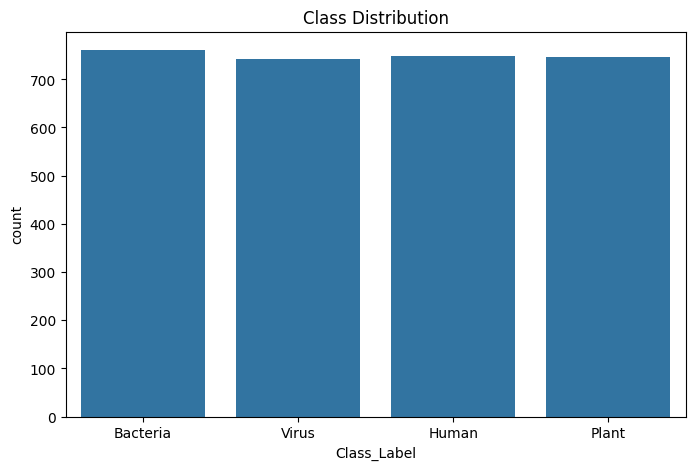

In [121]:
plt.figure(figsize=(8,5))
sns.countplot(x='Class_Label', data=df)
plt.title("Class Distribution")
plt.show()


In [122]:
df.columns

Index(['Sample_ID', 'Sequence', 'GC_Content', 'AT_Content', 'Sequence_Length',
       'Num_A', 'Num_T', 'Num_C', 'Num_G', 'kmer_3_freq', 'Mutation_Flag',
       'Class_Label', 'Disease_Risk'],
      dtype='str')

In [123]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Class_Label_Encoded'] = le.fit_transform(df['Class_Label'])

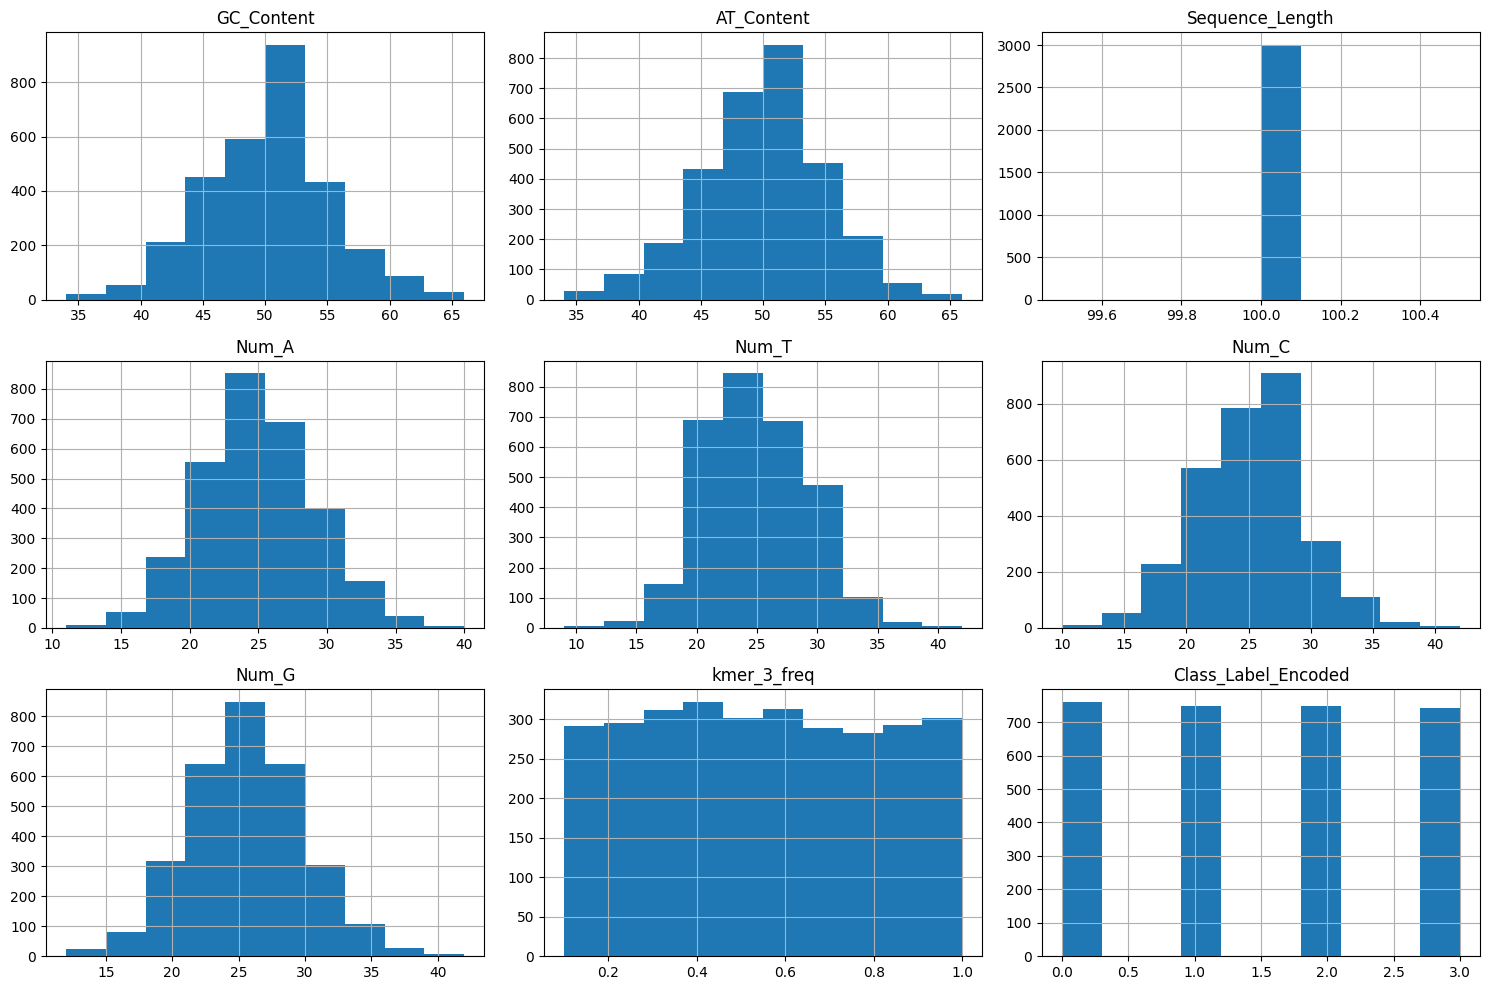

In [124]:
numerical_cols = [
    'GC_Content',
    'AT_Content',
    'Sequence_Length',
    'Num_A',
    'Num_T',
    'Num_C',
    'Num_G',
    'kmer_3_freq',
    'Class_Label_Encoded'
]
df[numerical_cols].hist(figsize=(15,10))
plt.tight_layout()
plt.show()

In [125]:
corr_with_target = df[numerical_cols].corr()['Class_Label_Encoded']
corr_with_target.sort_values(ascending=False)

Class_Label_Encoded    1.000000
AT_Content             0.041931
Num_T                  0.036498
Num_A                  0.012669
Num_C                 -0.010266
kmer_3_freq           -0.020621
Num_G                 -0.038718
GC_Content            -0.041931
Sequence_Length             NaN
Name: Class_Label_Encoded, dtype: float64

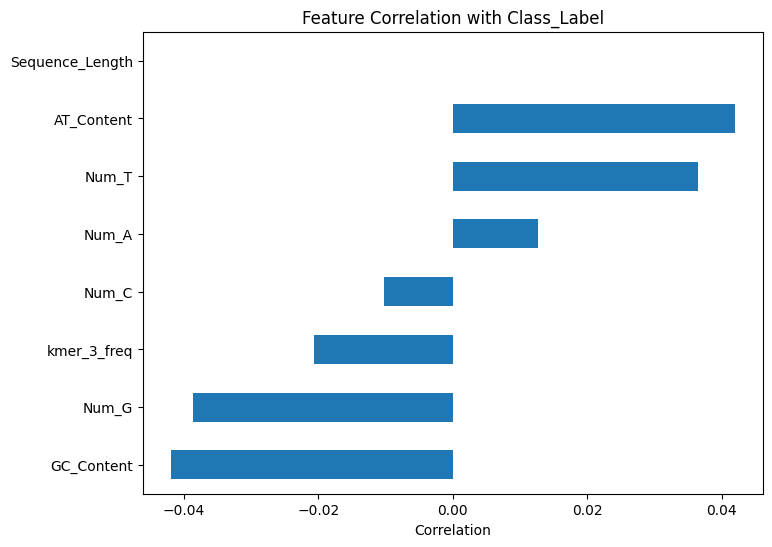

In [126]:
plt.figure(figsize=(8,6))

corr_with_target.drop('Class_Label_Encoded').sort_values().plot(
    kind='barh'
)

plt.title("Feature Correlation with Class_Label")
plt.xlabel("Correlation")
plt.show()

these fetures are +vely corelated to our target variable 

AT_Content             
Num_T                  
Num_A                  
Num_C 

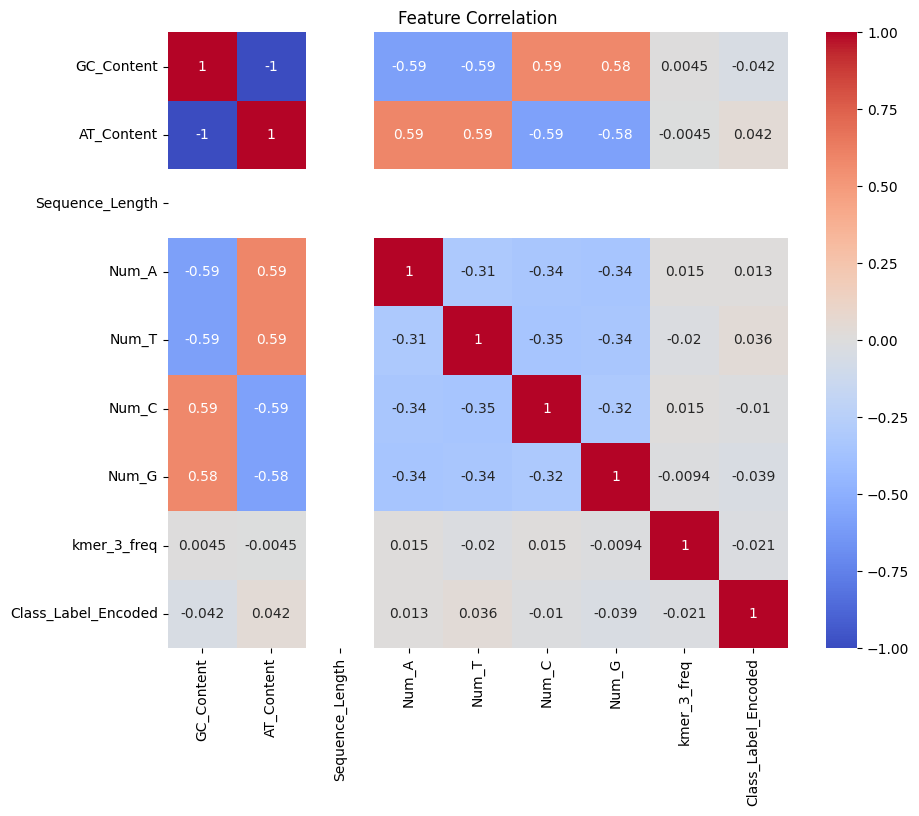

In [127]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df[numerical_cols].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Feature Correlation")
plt.show()

In [128]:
df['Sequence_Length'].describe()

count    3000.0
mean      100.0
std         0.0
min       100.0
25%       100.0
50%       100.0
75%       100.0
max       100.0
Name: Sequence_Length, dtype: float64

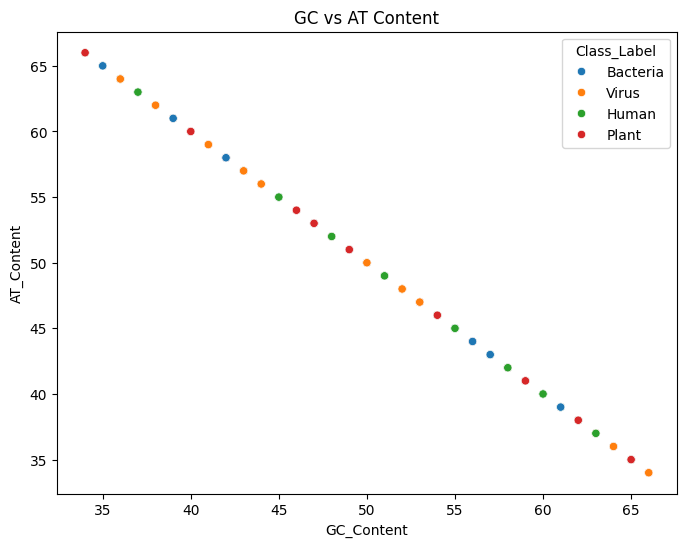

In [129]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='GC_Content',
    y='AT_Content',
    hue='Class_Label',
    data=df
)

plt.title("GC vs AT Content")
plt.show()

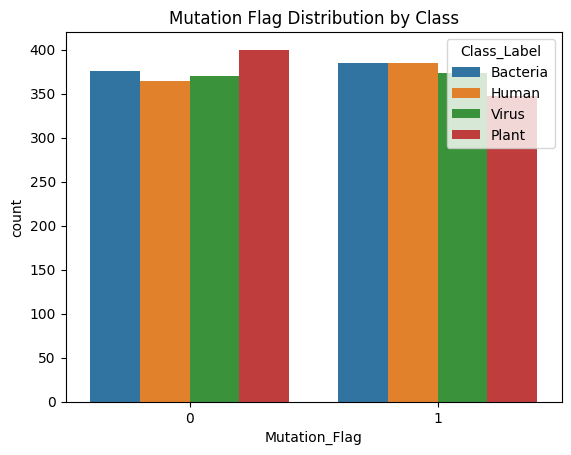

In [130]:
sns.countplot(x='Mutation_Flag', hue='Class_Label', data=df)
plt.title("Mutation Flag Distribution by Class")
plt.show()

In [131]:
valid_chars = set("ATGC")

def valid(seq):
    return set(seq).issubset(valid_chars)

df['Valid_Sequence'] = df['Sequence'].apply(valid)

df['Valid_Sequence'].value_counts()

Valid_Sequence
True    3000
Name: count, dtype: int64

In [132]:
df

,Sample_ID,Sequence,GC_Content,AT_Content,Sequence_Length,Num_A,Num_T,Num_C,Num_G,kmer_3_freq,Mutation_Flag,Class_Label,Disease_Risk,Class_Label_Encoded,Valid_Sequence
0,SAMPLE_1,CTTTCGGGATACTTTTGGGATGGTCTTGGTCAAGGGTTTTAGCCCG...,50.0,50.0,100,22,28,19,31,0.986,0,Bacteria,High,0,True
1,SAMPLE_2,TTGACCAAATTTGATTGGAAGTGGTAAGCGCGTATTCCTAGCATCA...,45.0,55.0,100,27,28,22,23,0.486,1,Virus,Medium,3,True
2,SAMPLE_3,GCGTGAGTTCTAATTTAAAAAGTCGTAACACGTACCCCGGCGTGTA...,51.0,49.0,100,26,23,30,21,0.367,1,Bacteria,Low,0,True
3,SAMPLE_4,ACTACGCGGACAAGAACCAACAGAACCTGGTTTTCGCAAGGGAGTG...,55.0,45.0,100,28,17,23,32,0.404,0,Human,Medium,1,True
4,SAMPLE_5,TTCAATGCAGATTGAAAGTTACTTTCATCTGCCCTATGGGTCCCTT...,46.0,54.0,100,24,30,25,21,0.818,0,Human,High,1,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,SAMPLE_2996,GATCAGCCCATACACCAAATCAATTGCATACATGTCCGATGTAACA...,46.0,54.0,100,30,24,27,19,0.786,1,Plant,Medium,2,True
2996,SAMPLE_2997,TGTTGTGTGTCTGATGATAGGTCATACCGCCTCGAAACATCACCAT...,49.0,51.0,100,28,23,24,25,0.831,0,Plant,Medium,2,True
2997,SAMPLE_2998,GACCCACTAAAAGTCTTCGTCTCCTTCCGATGGGAATTTTCGCCGA...,53.0,47.0,100,21,26,30,23,0.140,0,Virus,Medium,3,True
2998,SAMPLE_2999,CCAAAGGATATCTGTAATTGTTGCAGCGCCCCTACAATTTGAGCAC...,46.0,54.0,100,26,28,25,21,0.685,0,Plant,Medium,2,True


Sequence_Length has 0 corealation with our target variable so removinng it 

In [138]:
new_df=df.drop(columns=['Disease_Risk','Valid_Sequence','Class_Label','Sequence_Length'])
new_df.head()

,Sample_ID,Sequence,GC_Content,AT_Content,Num_A,Num_T,Num_C,Num_G,kmer_3_freq,Mutation_Flag,Class_Label_Encoded
0,SAMPLE_1,CTTTCGGGATACTTTTGGGATGGTCTTGGTCAAGGGTTTTAGCCCG...,50.0,50.0,22,28,19,31,0.986,0,0
1,SAMPLE_2,TTGACCAAATTTGATTGGAAGTGGTAAGCGCGTATTCCTAGCATCA...,45.0,55.0,27,28,22,23,0.486,1,3
2,SAMPLE_3,GCGTGAGTTCTAATTTAAAAAGTCGTAACACGTACCCCGGCGTGTA...,51.0,49.0,26,23,30,21,0.367,1,0
3,SAMPLE_4,ACTACGCGGACAAGAACCAACAGAACCTGGTTTTCGCAAGGGAGTG...,55.0,45.0,28,17,23,32,0.404,0,1
4,SAMPLE_5,TTCAATGCAGATTGAAAGTTACTTTCATCTGCCCTATGGGTCCCTT...,46.0,54.0,24,30,25,21,0.818,0,1


In [139]:
corr_target = new_df.corr(numeric_only=True)['Class_Label_Encoded']
corr_target.sort_values(ascending=False)

Class_Label_Encoded    1.000000
AT_Content             0.041931
Num_T                  0.036498
Num_A                  0.012669
Num_C                 -0.010266
Mutation_Flag         -0.013756
kmer_3_freq           -0.020621
Num_G                 -0.038718
GC_Content            -0.041931
Name: Class_Label_Encoded, dtype: float64

## EDA Summary

- Loaded the dataset using Pandas.
- Checked the shape, columns, and data types.
- Checked for missing values and duplicate rows.
- created new DATA FRAME (new_df) with out the unnecessary columns.
- Checked the distribution of `Class_Label`.
- Converted `Class_Label` into numerical values using `LabelEncoder`.
- Analyzed numerical columns:
  - `GC_Content`
  - `AT_Content`
  - `Sequence_Length`
  - `Num_A`, `Num_T`, `Num_C`, `Num_G`
  - `kmer_3_freq`
- Calculated feature correlations using `df.corr()`.
- Visualized correlations using a heatmap.
- Checked which features were more related to `Class_Label_Encoded`.